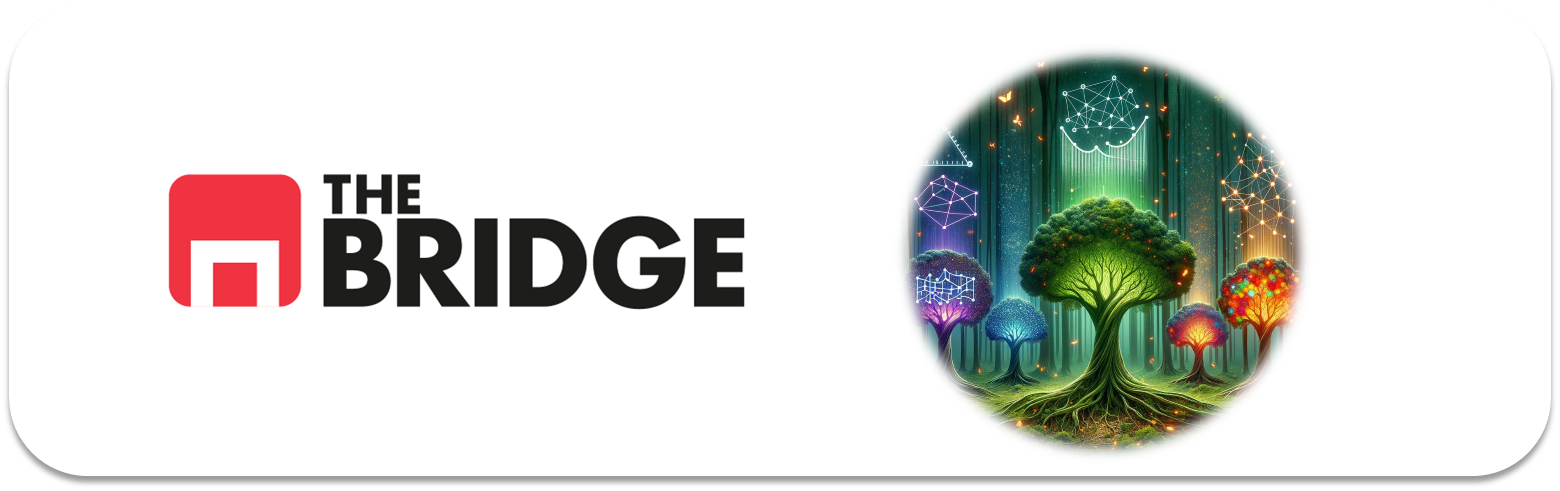

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [ ]:
# Librerías básicas
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from bootcampviztools import (
    pinta_distribucion_categoricas,
    plot_categorical_relationship,
    plot_categorical_numerical_relationship,
    plot_combined_graphs,
    plot_grouped_boxplots,
    plot_grouped_histograms,
    grafico_dispersion_con_correlacion,
)

# Preprocesado y split
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
)

pd.set_option("display.max_columns", None)
np.random.seed(42)
SEED = 42

### Ejercicio 1: Carga y primera exploración de los datos

In [ ]:
df = pd.read_csv("bankfull.csv", sep=";")  # coloca bankfull.csv en la misma carpeta que este notebook
print(df.shape)
df.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Comprobamos tipos de dato, nulos y duplicados. Fíjate que este dataset **no tiene NaNs "de verdad"**, pero varias columnas categóricas (`job`, `education`, `contact`, `poutcome`) usan la etiqueta `"unknown"` como valor cuando el dato no se conoce. La tratamos como una categoría más (no la imputamos), porque el propio hecho de "no saberlo" puede ser informativo.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [ ]:
print("Duplicados:", df.duplicated().sum())
print()
print("Nulos por columna:")
print(df.isna().sum())
print()
print("Valores 'unknown' por columna categórica:")
for c in df.select_dtypes(include=["object", "str"]).columns:
    n_unknown = (df[c] == "unknown").sum()
    if n_unknown > 0:
        print(f"  {c}: {n_unknown} ({n_unknown/len(df):.1%})")

Duplicados: 0

Nulos por columna:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Valores 'unknown' por columna categórica:
  job: 288 (0.6%)
  education: 1857 (4.1%)
  contact: 13020 (28.8%)
  poutcome: 36959 (81.7%)


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


### Ejercicio 2: Identificación y análisis del target

El target es `y`: si el cliente ha contratado o no el depósito a plazo tras la campaña ("yes"/"no"). Es un problema de **clasificación binaria**.

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


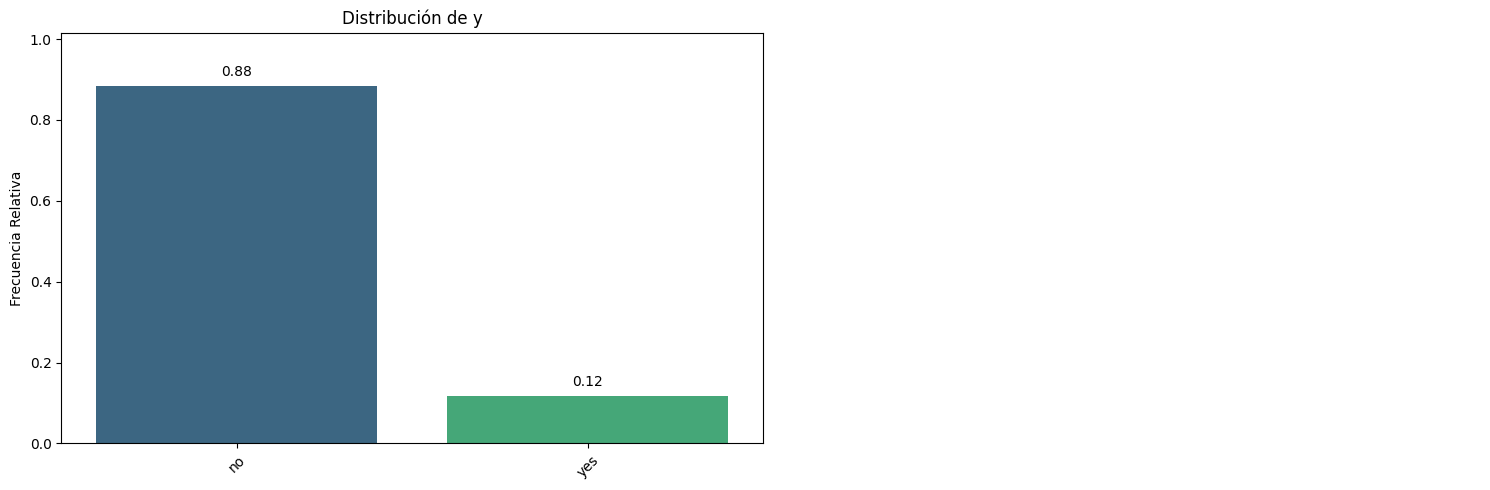

In [ ]:
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True))

pinta_distribucion_categoricas(df, ["y"], relativa=True, mostrar_valores=True)

**El target está claramente desbalanceado**: solo ~11.7% de los clientes contactados terminan contratando el depósito, frente a ~88.3% que no lo hacen. Esto es importante porque:
- La **accuracy** por sí sola puede ser engañosa (un modelo "tonto" que siempre prediga "no" ya acertaría el 88% de las veces).
- Tendremos que fijarnos en métricas como **recall**, **precision**, **f1** y **ROC-AUC** para la clase minoritaria ("yes"), y considerar el hiperparámetro `class_weight` en la optimización.
- Usaremos `stratify=y` en el split para mantener la misma proporción en train y test.

### Ejercicio 3: Mini EDA de las variables predictoras

Distribución de las variables numéricas:

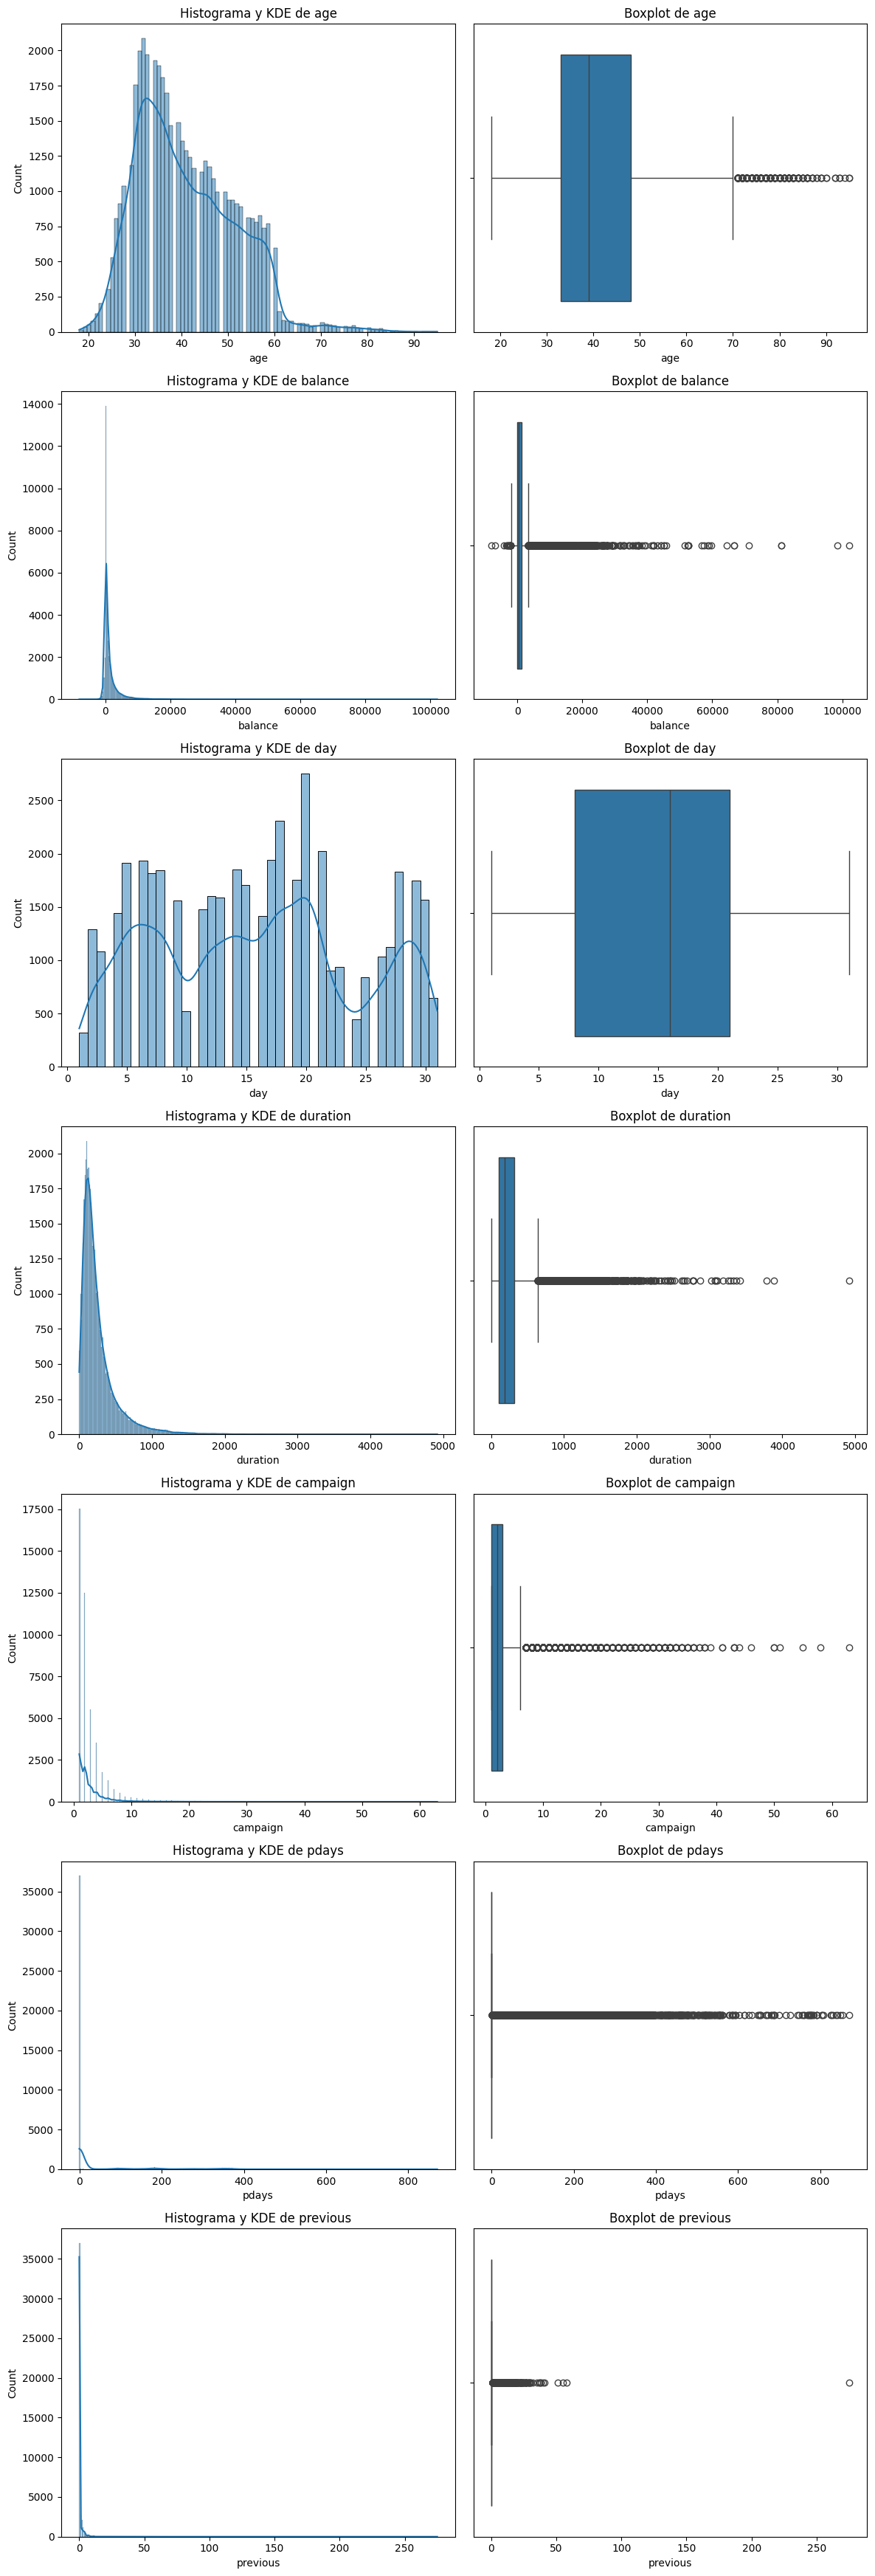

In [ ]:
num_cols_eda = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
plot_combined_graphs(df, num_cols_eda)

Vemos varias variables con **outliers y colas largas** (`balance`, `duration`, `campaign`, `previous`), típico de variables de conteo/importes económicos. Los árboles de decisión son robustos a outliers y no requieren escalado, así que no vamos a tratarlos de forma agresiva (no recortamos ni transformamos), aunque sí lo tendremos en cuenta para el modelo de regresión logística (que sí escalaremos).

Relación de algunas variables categóricas con el target:

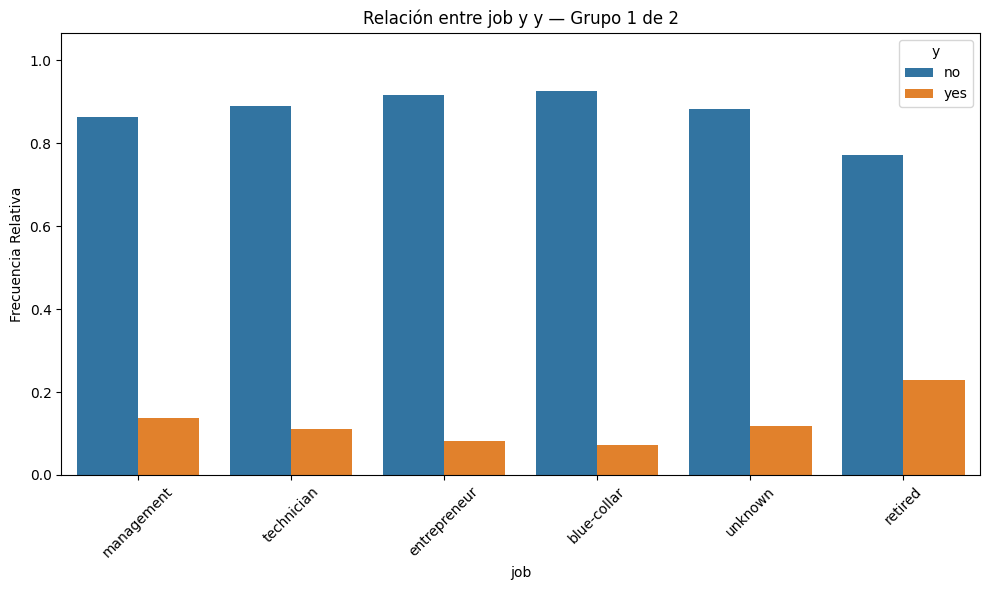

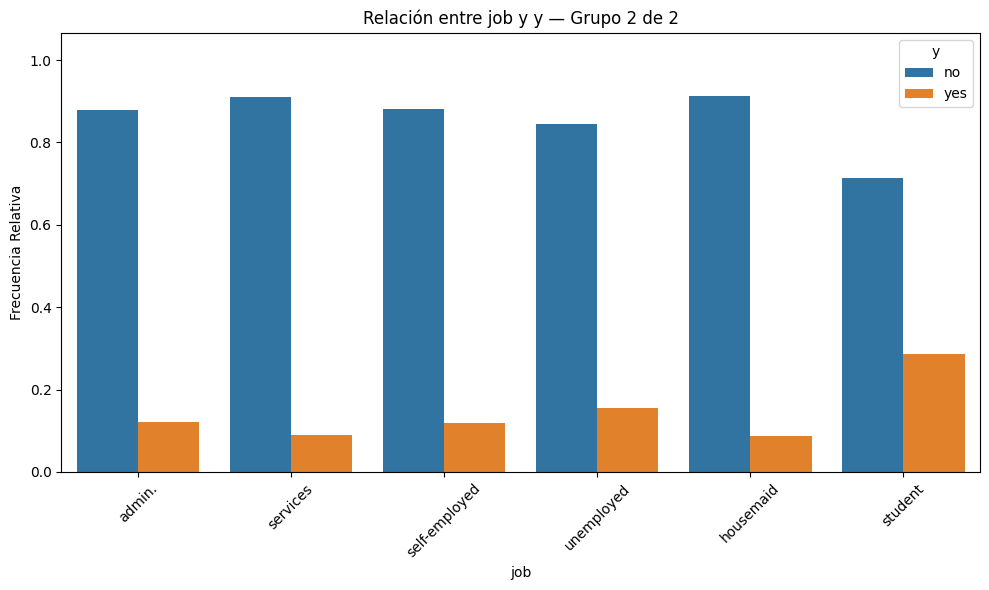

In [ ]:
plot_categorical_relationship(df, "job", "y", relative_freq=True, size_group=6)

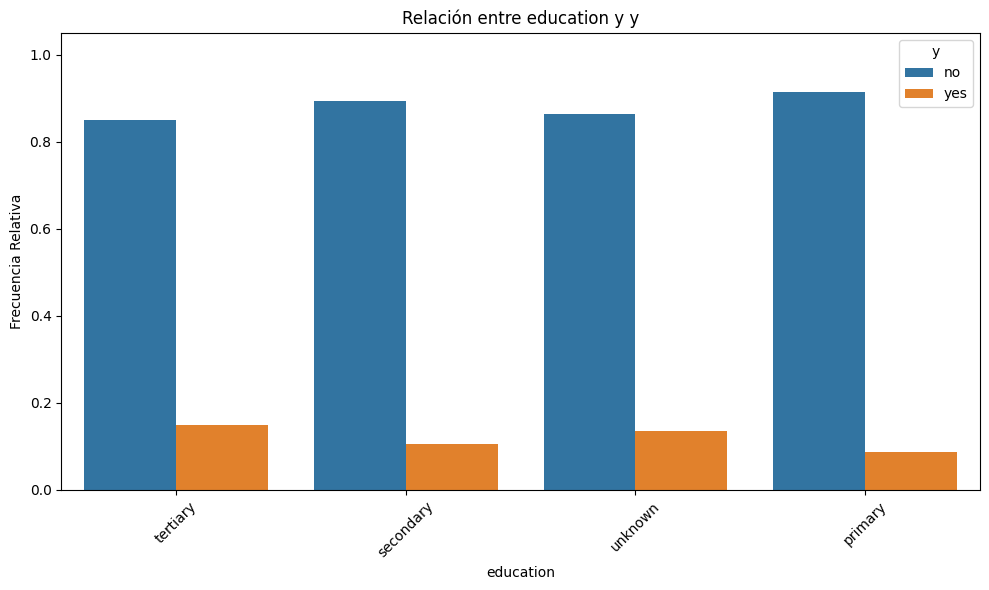

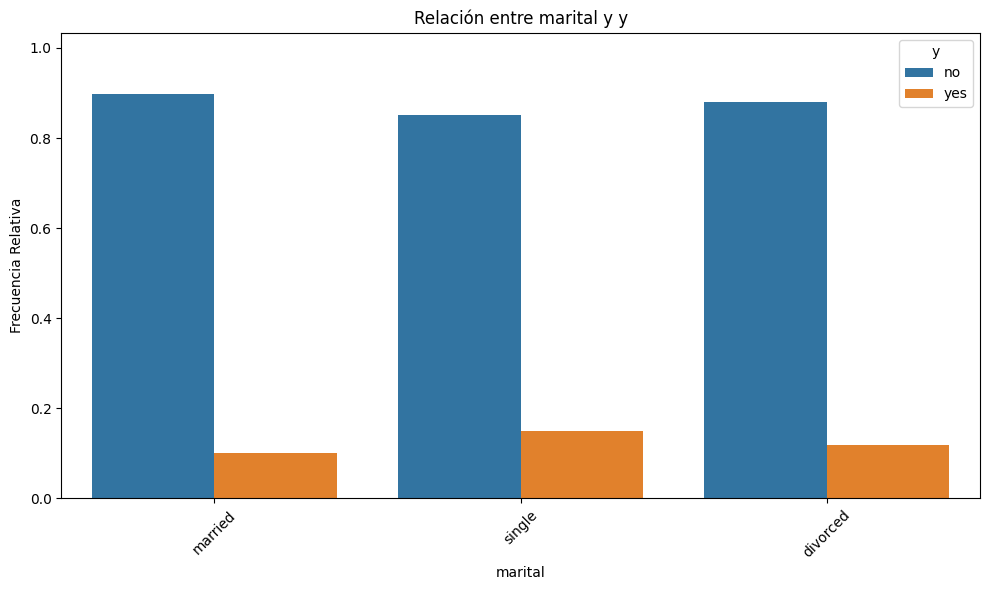

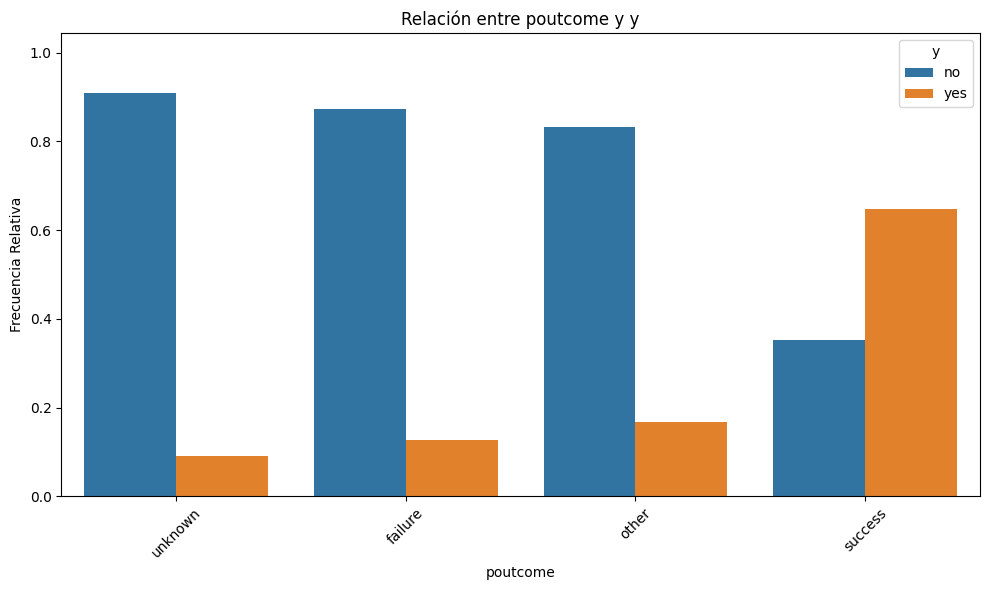

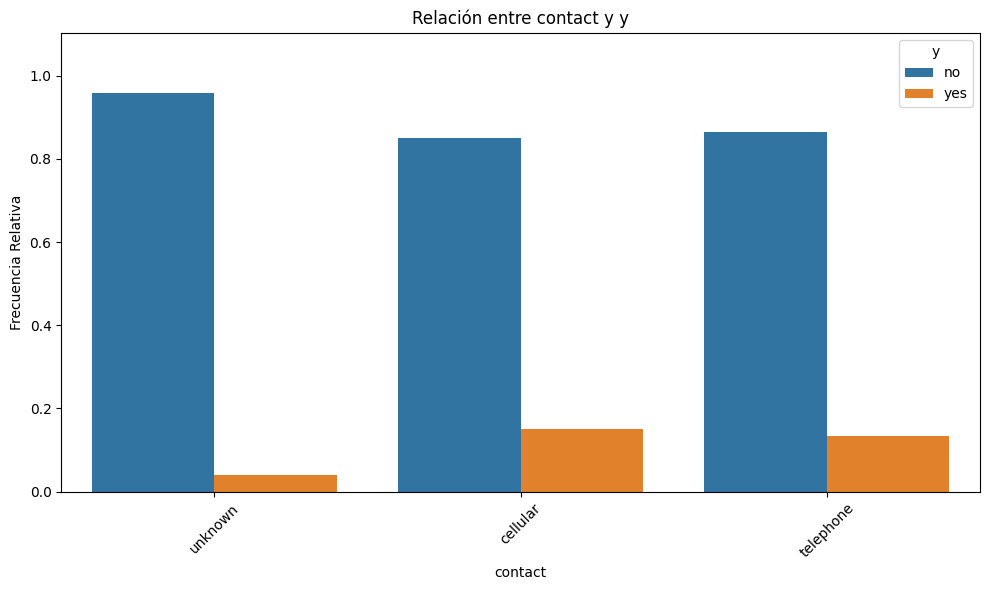

In [ ]:
plot_categorical_relationship(df, "education", "y", relative_freq=True)
plot_categorical_relationship(df, "marital", "y", relative_freq=True)
plot_categorical_relationship(df, "poutcome", "y", relative_freq=True)
plot_categorical_relationship(df, "contact", "y", relative_freq=True)

Se observan diferencias claras en la tasa de conversión: estudiantes y jubilados convierten notablemente más que blue-collar/entrepreneur; los clientes con `poutcome="success"` en una campaña anterior convierten mucho más que el resto; el contacto vía `cellular` convierte más que `telephone`/`unknown`. Son señales de que estas variables van a aportar información al modelo.

Relación de variables numéricas con el target:

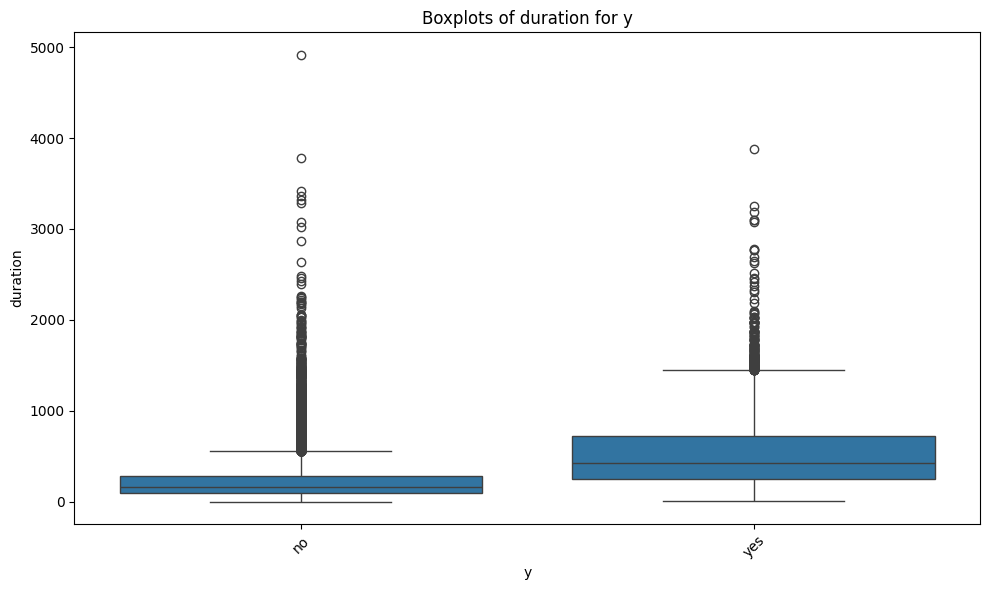

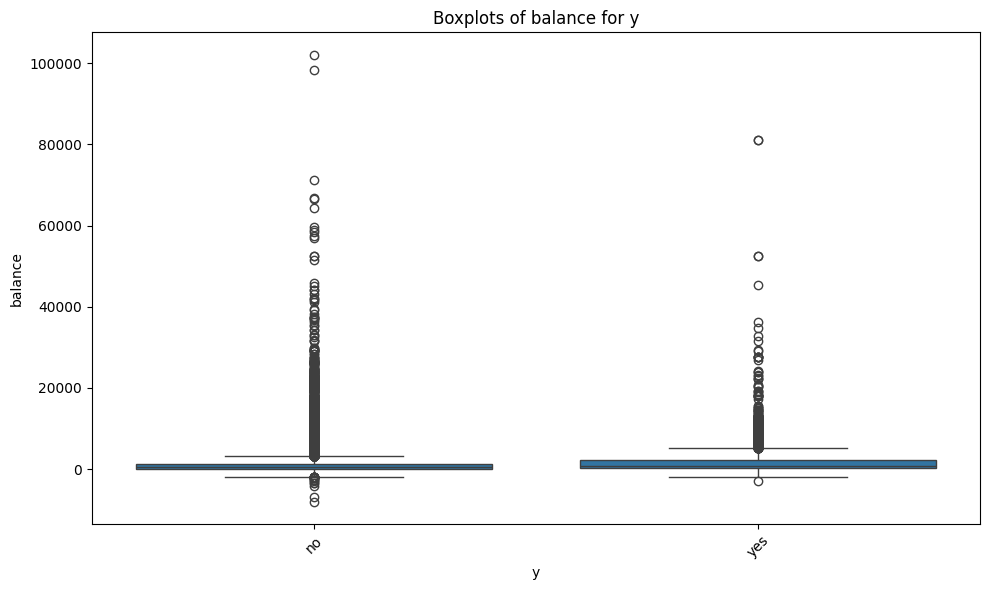

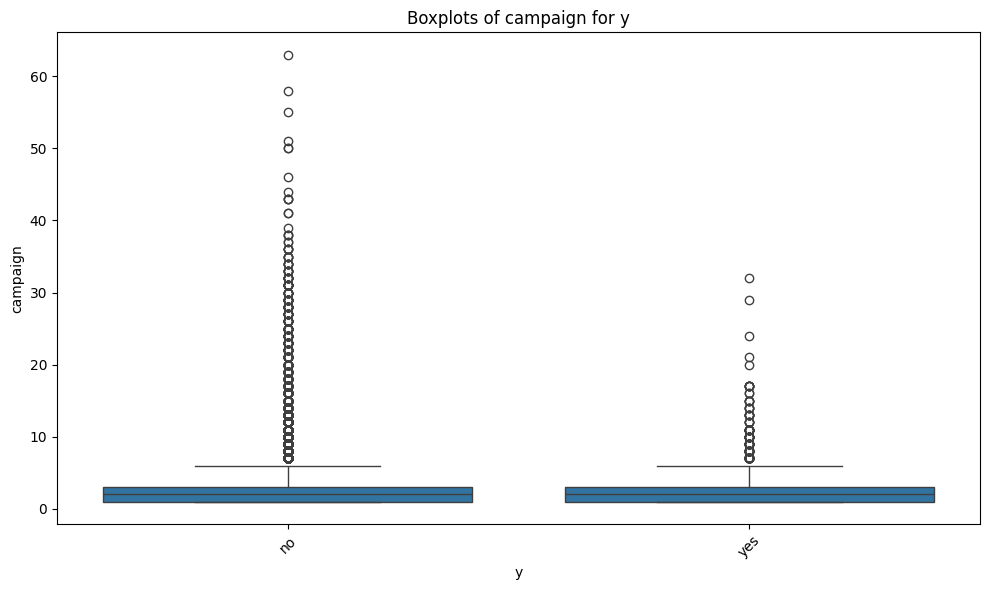

In [ ]:
plot_grouped_boxplots(df, "y", "duration")
plot_grouped_boxplots(df, "y", "balance")
plot_grouped_boxplots(df, "y", "campaign")

`duration` (duración de la última llamada) muestra una diferencia muy marcada entre "yes" y "no": las llamadas que terminan en venta duran bastante más. Esto tiene sentido... pero **hay que tener cuidado**: la documentación oficial del dataset (UCI Bank Marketing) advierte de que `duration` **no se conoce hasta después de hacer la llamada**, por lo que no está disponible en el momento de decidir a quién llamar. Usarla da un modelo "de laboratorio" muy bueno pero poco realista para producción (data leakage temporal). Lo mantenemos en el modelo principal siguiendo el enunciado de la práctica (para comparar de forma directa con Random Forest de sesiones futuras y por ser el enfoque estándar de este dataset), pero lo señalamos explícitamente en las conclusiones y entrenamos también, a modo de contraste, una versión sin `duration`.

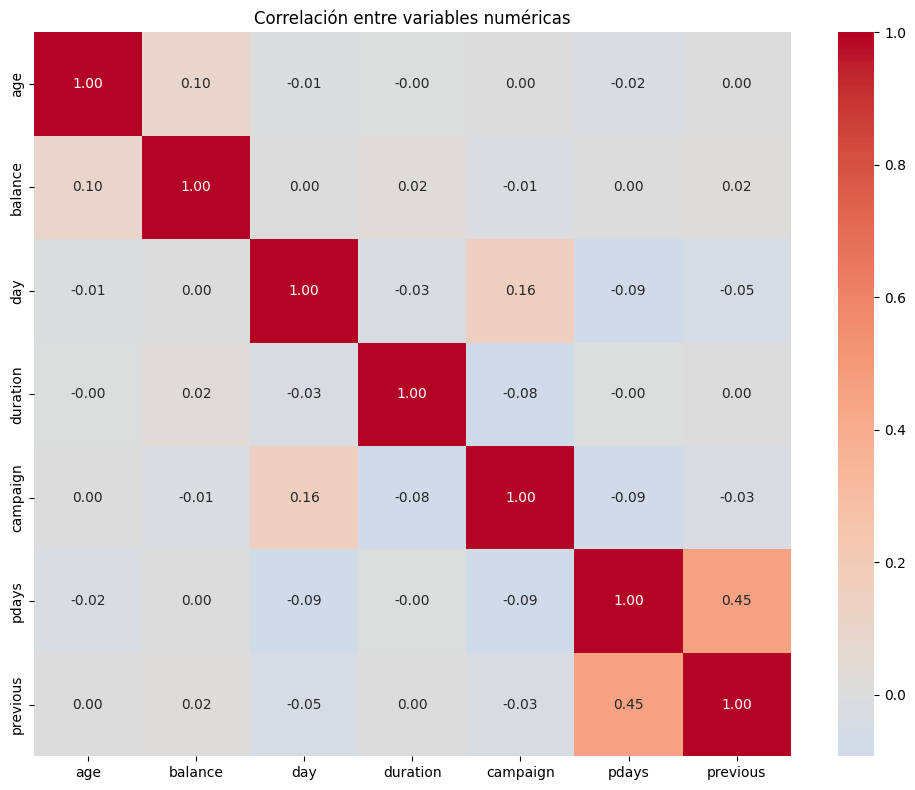

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[num_cols_eda].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

No hay correlaciones fuertes entre las variables numéricas entre sí (más allá de `pdays` y `previous`, lo cual es esperable porque ambas hablan de contactos previos), así que no hace falta descartar ninguna por colinealidad.

### Ejercicio 4: Limpieza, tratamiento y selección de variables

- No imputamos nada: no hay NaNs reales, y `"unknown"` se deja como categoría propia.
- Creamos una variable derivada `contactado_antes` a partir de `pdays` (que vale -1 cuando el cliente nunca fue contactado antes), porque ese -1 no es una magnitud continua real sino un código especial.
- Convertimos el target a binario (0/1).
- Separamos variables categóricas y numéricas para aplicar un preprocesado distinto a cada tipo.

In [ ]:
df_model = df.copy()

# 0/1 target
df_model["y"] = (df_model["y"] == "yes").astype(int)

# pdays = -1 significa "nunca contactado antes": lo convertimos en una variable binaria explícita
df_model["contactado_antes"] = (df_model["pdays"] != -1).astype(int)

cat_cols = ["job", "marital", "education", "default", "housing", "loan",
            "contact", "month", "poutcome"]
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays",
            "previous", "contactado_antes"]

X = df_model[cat_cols + num_cols]
y = df_model["y"]

X.head()

,job,marital,education,default,housing,loan,contact,month,poutcome,age,balance,day,duration,campaign,pdays,previous,contactado_antes
0,management,married,tertiary,no,yes,no,unknown,may,unknown,58,2143,5,261,1,-1,0,0
1,technician,single,secondary,no,yes,no,unknown,may,unknown,44,29,5,151,1,-1,0,0
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,33,2,5,76,1,-1,0,0
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,47,1506,5,92,1,-1,0,0
4,unknown,single,unknown,no,no,no,unknown,may,unknown,33,1,5,198,1,-1,0,0


### Ejercicio 5: Train / Test split

Usamos `stratify=y` para que la proporción de clase minoritaria ("yes") se mantenga igual en train y test, dado el desbalanceo que vimos antes.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train:", X_train.shape, "  Test:", X_test.shape)
print("Proporción de 'yes' en train:", y_train.mean().round(4))
print("Proporción de 'yes' en test :", y_test.mean().round(4))

Train: (36168, 17)   Test: (9043, 17)
Proporción de 'yes' en train: 0.117
Proporción de 'yes' en test : 0.117


### Ejercicio 6: Preprocesado

Los árboles de decisión no necesitan escalado, pero sí necesitamos convertir las variables categóricas a numéricas. Usamos `OneHotEncoder` para las categóricas (con `handle_unknown="ignore"` por seguridad) y dejamos las numéricas tal cual, todo dentro de un `ColumnTransformer` + `Pipeline` para evitar fugas de información entre train y test.

In [ ]:
preprocessor_tree = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough",
)

### Ejercicio 7: Primer modelo de árbol (sin optimizar)

Antes de optimizar, entrenamos un árbol con los hiperparámetros por defecto para tener un primer punto de referencia y ver si el enfoque general funciona.

In [ ]:
tree_pipe = Pipeline([
    ("prep", preprocessor_tree),
    ("clf", DecisionTreeClassifier(random_state=SEED)),
])

tree_pipe.fit(X_train, y_train)

cv_scores = cross_val_score(tree_pipe, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1)
print("Árbol por defecto - ROC-AUC en CV (train):", cv_scores.mean().round(4), "+/-", cv_scores.std().round(4))
print("Profundidad del árbol por defecto:", tree_pipe.named_steps["clf"].get_depth())
print("Nº de hojas:", tree_pipe.named_steps["clf"].get_n_leaves())

Árbol por defecto - ROC-AUC en CV (train): 0.7077 +/- 0.0083
Profundidad del árbol por defecto: 34
Nº de hojas: 2870


Un árbol sin restricciones alcanza una profundidad muy grande y muchísimas hojas: es una señal clara de que probablemente esté **sobreajustando** (memorizando el train), tal y como vimos en el notebook de regresión con árboles. Por eso el siguiente paso es optimizar los hiperparámetros para encontrar el punto de equilibrio bias-varianza.

### Ejercicio 8: Optimización de hiperparámetros (obligatorio)

Elegimos un grid centrado en los hiperparámetros que más controlan la complejidad (y por tanto el overfitting) del árbol, como vimos en la sesión de árboles de regresión:

- **`max_depth`**: controla directamente cuánto puede crecer el árbol. Probamos valores moderados (4-10) frente a "sin límite" (`None`), para ver el efecto de restringir la profundidad.
- **`min_samples_leaf`**: mínimo de muestras por hoja. Con un dataset de 45k filas, exigir un mínimo (10, 30) evita hojas hiperespecíficas de 1-2 muestras.
- **`min_samples_split`**: mínimo de muestras para dividir un nodo.
- **`criterion`**: `gini` vs `entropy`, para comparar el criterio de impureza.
- **`class_weight`**: dado el desbalanceo del target, probamos `None` frente a `"balanced"` para ver si compensa la clase minoritaria.

Usamos `GridSearchCV` con `cv=5` y `scoring="roc_auc"` (más informativo que accuracy con un target desbalanceado).

In [ ]:
param_grid = {
    "clf__max_depth": [4, 6, 8, 10, None],
    "clf__min_samples_leaf": [1, 10, 30],
    "clf__min_samples_split": [2, 20],
    "clf__criterion": ["gini", "entropy"],
    "clf__class_weight": [None, "balanced"],
}

grid_search = GridSearchCV(
    tree_pipe,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor ROC-AUC en CV (train):", grid_search.best_score_.round(4))

Mejores hiperparámetros: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 30, 'clf__min_samples_split': 2}
Mejor ROC-AUC en CV (train): 0.9069


In [ ]:
best_tree = grid_search.best_estimator_
best_clf = best_tree.named_steps["clf"]
print("Profundidad final:", best_clf.get_depth())
print("Nº de hojas:", best_clf.get_n_leaves())

Profundidad final: 10
Nº de hojas: 188


Visualizamos las primeras ramas del árbol óptimo (limitamos `max_depth` solo para la visualización, no para el modelo) y la importancia de cada variable:

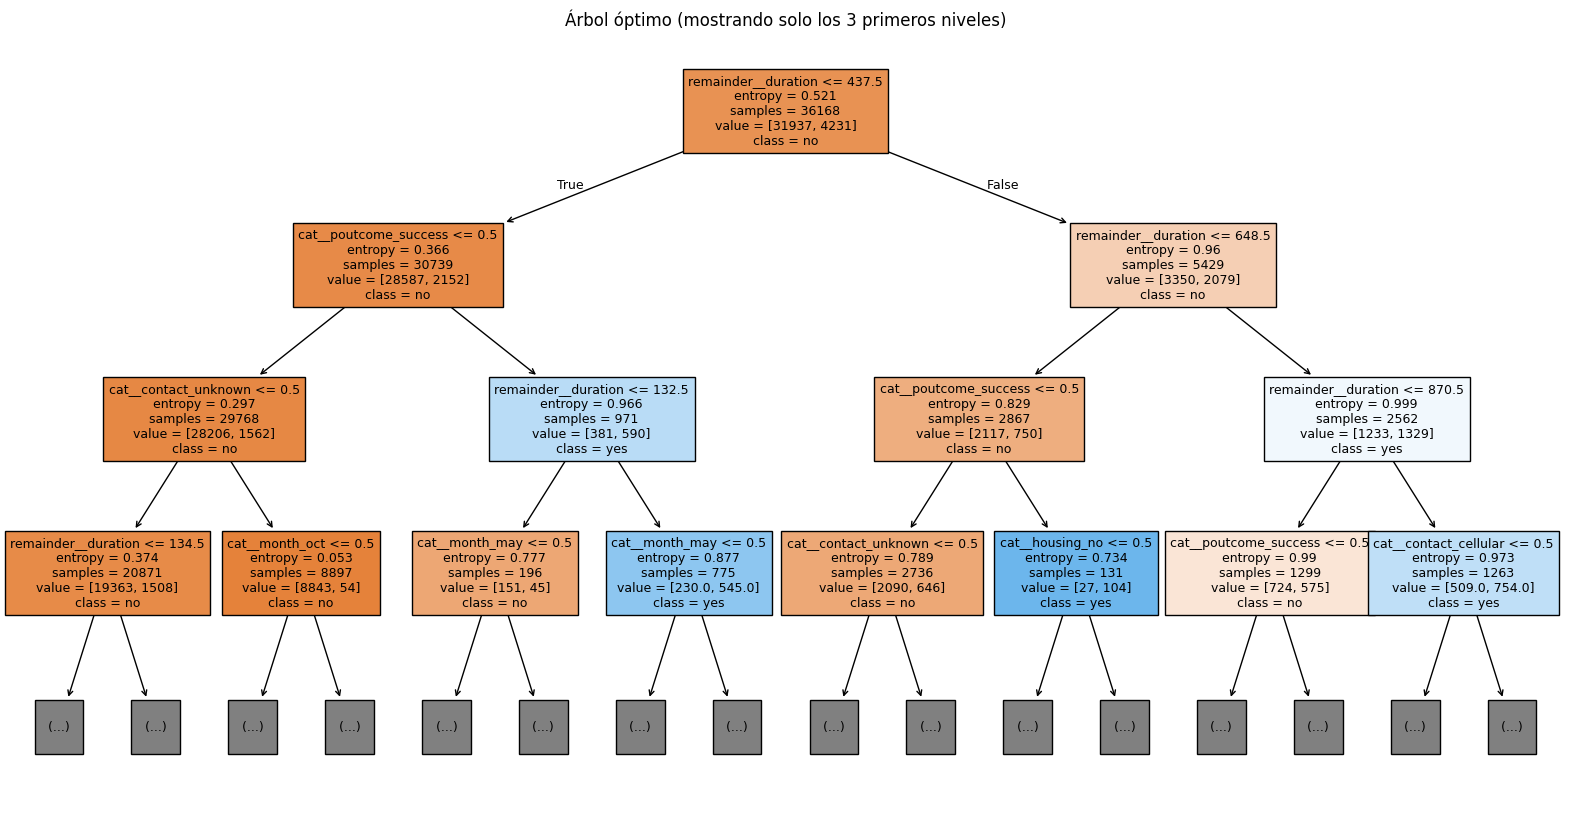

In [ ]:
feature_names = best_tree.named_steps["prep"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(best_clf, feature_names=feature_names, class_names=["no", "yes"],
          filled=True, max_depth=3, fontsize=9)
plt.title("Árbol óptimo (mostrando solo los 3 primeros niveles)")
plt.show()

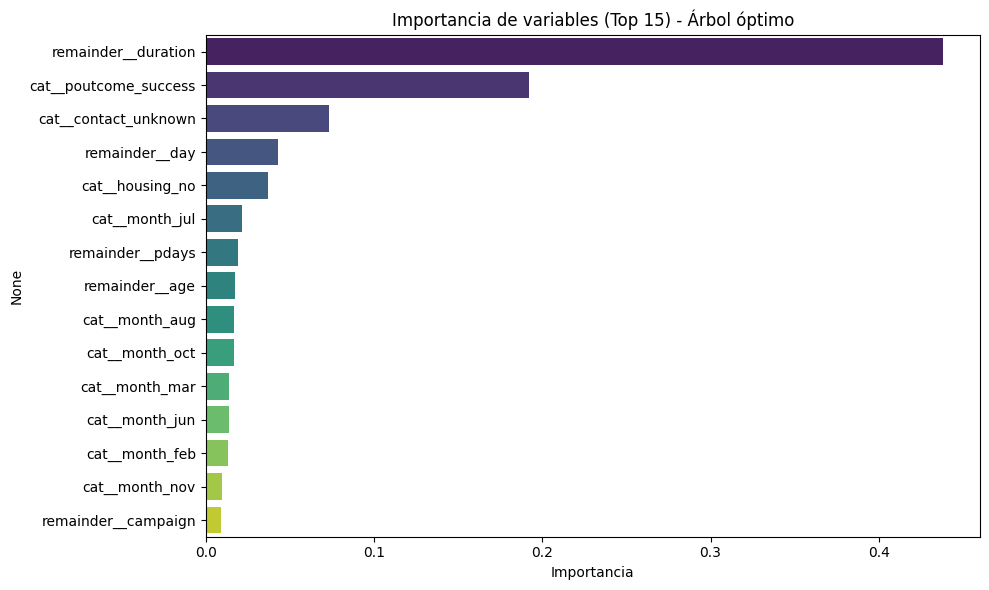

In [ ]:
importances = pd.Series(best_clf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette="viridis")
plt.title("Importancia de variables (Top 15) - Árbol óptimo")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

Como cabía esperar por el EDA, `duration` es, con diferencia, la variable más importante, seguida de variables relacionadas con el resultado de campañas anteriores (`poutcome`) y con el mes/día de contacto. Esto confirma visualmente la advertencia sobre `duration` que comentamos antes.

### Ejercicio 9: Comparación con el modelo baseline (Regresión Logística)

Como pide el enunciado, comparamos el árbol optimizado con una **regresión logística sin optimizar** (hiperparámetros por defecto). A diferencia del árbol, la regresión logística sí es sensible a la escala de las variables numéricas, así que en su pipeline añadimos un `StandardScaler`.

In [ ]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

logreg_pipe = Pipeline([
    ("prep", preprocessor_lr),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])

logreg_pipe.fit(X_train, y_train)

cv_scores_lr = cross_val_score(logreg_pipe, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1)
print("Regresión logística (baseline) - ROC-AUC en CV (train):", cv_scores_lr.mean().round(4), "+/-", cv_scores_lr.std().round(4))
print("Árbol optimizado          - ROC-AUC en CV (train):", grid_search.best_score_.round(4))

Regresión logística (baseline) - ROC-AUC en CV (train): 0.9069 +/- 0.0021
Árbol optimizado          - ROC-AUC en CV (train): 0.9069


En validación cruzada sobre train, ambos modelos quedan muy cerca en ROC-AUC. Vamos a confirmarlo con la evaluación definitiva sobre el conjunto de test, que es el que de verdad importa.

### Ejercicio 10: Evaluación final contra test (obligatorio)

Evaluamos ambos modelos (árbol optimizado y regresión logística baseline) sobre el conjunto de test, que no se ha usado en ningún momento del entrenamiento ni de la optimización.

In [ ]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metrics = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba

metrics_tree, y_pred_tree, y_proba_tree = evaluar_modelo("Árbol optimizado", best_tree, X_test, y_test)
metrics_lr, y_pred_lr, y_proba_lr = evaluar_modelo("Regresión logística (baseline)", logreg_pipe, X_test, y_test)

results_df = pd.DataFrame([metrics_tree, metrics_lr]).set_index("modelo").round(4)
results_df

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Árbol optimizado,0.9006,0.6097,0.4178,0.4958,0.9113
Regresión logística (baseline),0.9011,0.6439,0.3469,0.4509,0.9056


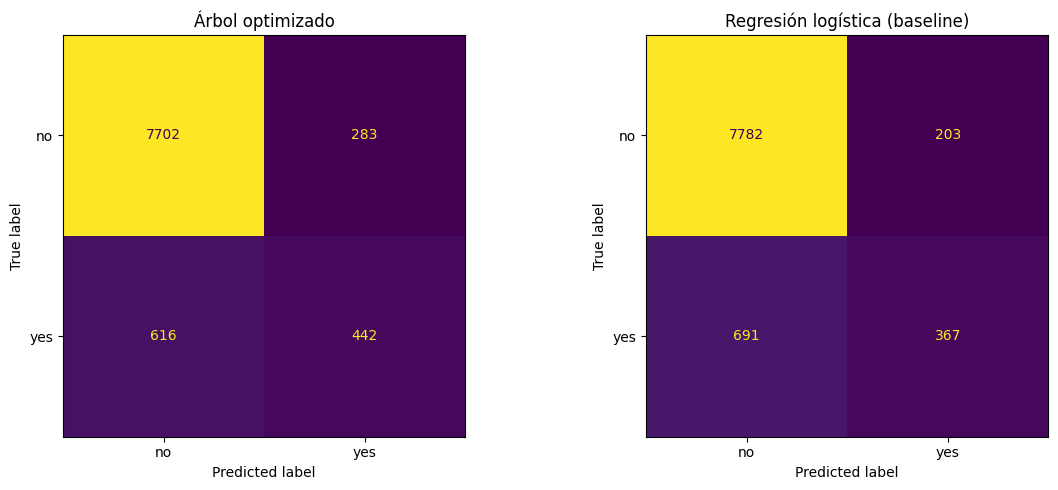

--- Árbol optimizado ---
              precision    recall  f1-score   support

          no       0.93      0.96      0.94      7985
         yes       0.61      0.42      0.50      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043

--- Regresión logística ---
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7985
         yes       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, display_labels=["no", "yes"], ax=axes[0], colorbar=False)
axes[0].set_title("Árbol optimizado")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=["no", "yes"], ax=axes[1], colorbar=False)
axes[1].set_title("Regresión logística (baseline)")
plt.tight_layout()
plt.show()

print("--- Árbol optimizado ---")
print(classification_report(y_test, y_pred_tree, target_names=["no", "yes"]))
print("--- Regresión logística ---")
print(classification_report(y_test, y_pred_lr, target_names=["no", "yes"]))

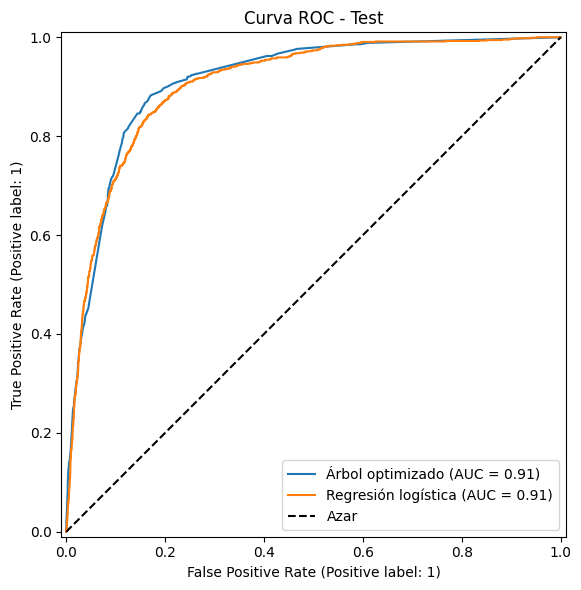

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_tree, name="Árbol optimizado", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Regresión logística", ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_title("Curva ROC - Test")
ax.legend()
plt.tight_layout()
plt.show()

### Extra: ¿qué pasa si quitamos `duration`?

Como comentamos en el EDA, `duration` no está disponible en el momento real de decidir si llamar o no a un cliente (solo se conoce *después* de la llamada). A modo de contraste, repetimos rápidamente la optimización del árbol **sin** `duration`, para tener una estimación más realista del rendimiento "en producción".

In [ ]:
num_cols_sin_duration = [c for c in num_cols if c != "duration"]
X_sin_duration = df_model[cat_cols + num_cols_sin_duration]

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X_sin_duration, y, test_size=0.2, random_state=SEED, stratify=y
)

preprocessor_tree2 = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough",
)
tree_pipe2 = Pipeline([("prep", preprocessor_tree2), ("clf", DecisionTreeClassifier(random_state=SEED))])

grid_search2 = GridSearchCV(tree_pipe2, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search2.fit(Xtr2, ytr2)

best_tree2 = grid_search2.best_estimator_
metrics_tree_sin_dur, _, _ = evaluar_modelo("Árbol optimizado (sin duration)", best_tree2, Xte2, yte2)
pd.DataFrame([metrics_tree_sin_dur]).set_index("modelo").round(4)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Árbol optimizado (sin duration),0.8169,0.3396,0.5983,0.4333,0.7786


Como era de esperar, sin `duration` el rendimiento cae de forma notable (ROC-AUC y recall más bajos). Esto confirma que buena parte del "éxito" del modelo principal depende de una variable que en un escenario real de campaña no tendríamos disponible antes de llamar. Es un matiz importante a la hora de valorar el modelo para un caso de uso real.

### Ejercicio 11: Valoración final

- **Target**: `y` (contratación del depósito) está desbalanceado (~11.7% "yes"), así que hemos priorizado ROC-AUC, recall y f1 sobre accuracy, y hemos estratificado el split.
- **Optimización de hiperparámetros**: el `GridSearchCV` sobre `max_depth`, `min_samples_leaf`, `min_samples_split`, `criterion` y `class_weight` mejora claramente al árbol por defecto (que sobreajustaba, con profundidad y nº de hojas muy altos) y reduce el overfitting al limitar la complejidad del árbol.
- **Comparación con el baseline**: el árbol optimizado y la regresión logística (sin optimizar) quedan muy próximos en ROC-AUC, pero el árbol consigue un **recall sensiblemente mejor** sobre la clase "yes" (identifica más clientes que sí contratarían), lo cual es relevante de cara al negocio, ya que el coste de "perder" un cliente potencial suele ser mayor que el de una llamada de más.
- **Variable más influyente**: `duration` domina claramente la importancia de variables, seguida de `poutcome`, `month` y variables relacionadas con contactos previos. Como `duration` no está disponible antes de realizar la llamada, el modelo "de producción" real debería evaluarse (y probablemente re-optimizarse) sin ella; hemos visto que, al quitarla, el rendimiento cae de forma notable.
- **Siguientes pasos razonables**: probar métodos de ensemble (Random Forest, Gradient Boosting) que suelen mejorar sobre un único árbol, ajustar el umbral de decisión (en vez de 0.5) para equilibrar precision/recall según el coste real de cada tipo de error, y considerar técnicas de balanceo de clases (undersampling/oversampling, SMOTE) además de `class_weight`.